In [1]:
# Import Required Libraries
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [2]:
# Import train_test_split for stratified sampling
from sklearn.model_selection import train_test_split

# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Flatten labels for stratified sampling
y_train_flat = y_train
y_test_flat = y_test

# Perform stratified sampling
subset_size = 1000  # Use 1000 samples for training and testing
x_train, _, y_train, _ = train_test_split(x_train, y_train_flat, train_size=subset_size, stratify=y_train_flat, random_state=42)
x_test, _, y_test, _ = train_test_split(x_test, y_test_flat, train_size=subset_size, stratify=y_test_flat, random_state=42)

# Normalize the images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape the data to include a channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [3]:
# Define the Environment for Reinforcement Learning
class MNISTEnvironment:
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
        self.current_index = 0

    def reset(self):
        self.current_index = 0
        return self.data[self.current_index]

    def step(self, action):
        reward = 1 if action == np.argmax(self.labels[self.current_index]) else -1
        self.current_index += 1
        done = self.current_index >= len(self.data)
        next_state = self.data[self.current_index] if not done else None
        return next_state, reward, done

In [4]:
# Build the Reinforcement Learning Agent
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

def build_agent(input_shape, num_actions):
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_actions, activation='linear')
    ])
    return model

input_shape = x_train.shape[1:]
num_actions = 10
agent_model = build_agent(input_shape, num_actions)

c:\Users\david\miniconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
# Train the Agent
import random

def train_agent(env, model, episodes, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01):
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    loss_fn = tf.keras.losses.MeanSquaredError()

    for episode in range(episodes):
        state = env.reset()
        state = np.expand_dims(state, axis=0)
        total_reward = 0

        while True:
            if random.random() < epsilon:
                action = random.randint(0, num_actions - 1)
            else:
                q_values = model.predict(state, verbose=0)
                action = np.argmax(q_values)

            next_state, reward, done = env.step(action)
            total_reward += reward

            if not done:
                next_state = np.expand_dims(next_state, axis=0)
                target = reward + gamma * np.max(model.predict(next_state, verbose=0))
            else:
                target = reward

            target_f = model.predict(state, verbose=0)
            target_f[0][action] = target

            with tf.GradientTape() as tape:
                predictions = model(state, training=True)
                loss = loss_fn(target_f, predictions)

            gradients = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))

            state = next_state if not done else None

            if done:
                break

        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        print(f"Episode {episode + 1}/{episodes}, Total Reward: {total_reward}")

env = MNISTEnvironment(x_train, y_train)
train_agent(env, agent_model, episodes=10)

Episode 1/10, Total Reward: -788
Episode 2/10, Total Reward: -806
Episode 3/10, Total Reward: -784
Episode 4/10, Total Reward: -772
Episode 5/10, Total Reward: -758
Episode 6/10, Total Reward: -760
Episode 7/10, Total Reward: -816
Episode 8/10, Total Reward: -784
Episode 9/10, Total Reward: -796
Episode 10/10, Total Reward: -770


In [8]:
# Evaluate the Agent's Performance
correct_predictions = 0
total_predictions = len(x_test)

for i in range(total_predictions):
    state = np.expand_dims(x_test[i], axis=0)
    q_values = agent_model.predict(state, verbose=0)
    action = np.argmax(q_values)
    if action == np.argmax(y_test[i]):
        correct_predictions += 1

accuracy = correct_predictions / total_predictions
print(f"Agent Accuracy: {accuracy * 100:.2f}%")

Agent Accuracy: 10.10%


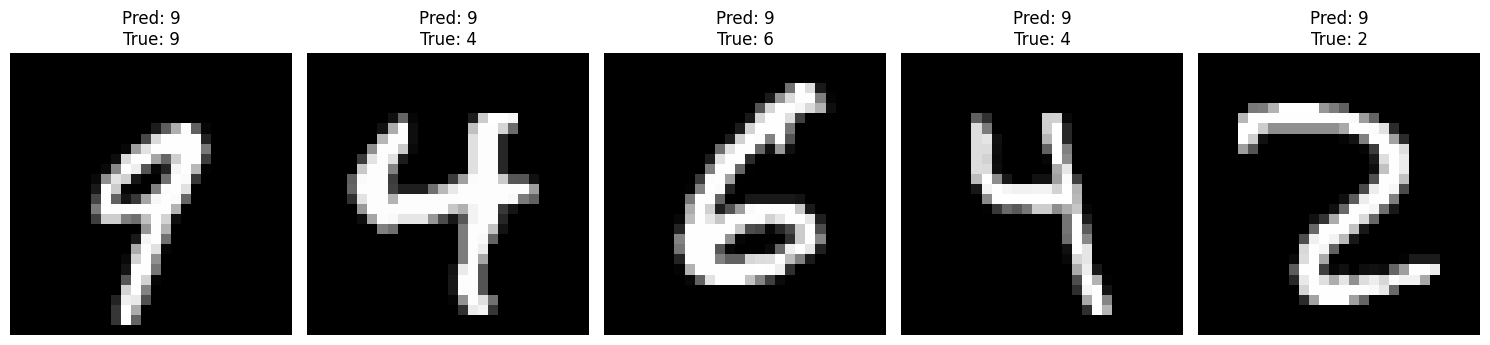

In [7]:
# Visualize Predictions with Ground Truth
import matplotlib.pyplot as plt

# Select a few test samples to visualize
num_samples = 5
indices = np.random.choice(len(x_test), num_samples, replace=False)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    state = np.expand_dims(x_test[idx], axis=0)
    q_values = agent_model.predict(state, verbose=0)
    predicted_label = np.argmax(q_values)
    true_label = np.argmax(y_test[idx])
    
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()